In [1]:
!pip install -q kagglehub tensorflow opencv-python-headless

In [24]:
import kagglehub
import shutil
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
import matplotlib.pyplot as plt
import numpy as np

In [3]:
path = kagglehub.dataset_download("fpeccia/weed-detection-in-soybean-crops")
data_dir = Path(path) / "dataset"
print("Путь к изображениям:", data_dir)

Путь к изображениям: C:\Users\user\.cache\kagglehub\datasets\fpeccia\weed-detection-in-soybean-crops\versions\1\dataset


In [4]:
data_dir = Path(path) / "dataset"

In [5]:
binary_dir = Path("binary_soil_vs_soybean")
binary_dir.mkdir(exist_ok=True)
(binary_dir / "0").mkdir(exist_ok=True)
(binary_dir / "1").mkdir(exist_ok=True)

In [6]:
for img in (data_dir / "soil").iterdir():
    if img.suffix.lower() == ".tif":
        shutil.copy(img, binary_dir / "0" / img.name)

for img in (data_dir / "soybean").iterdir():
    if img.suffix.lower() == ".tif":
        
        shutil.copy(img, binary_dir / "1" / img.name)

print(f"Класс 0 (soil):     {len(list((binary_dir/'0').iterdir()))} изображений")
print(f"Класс 1 (soybean):  {len(list((binary_dir/'1').iterdir()))} изображений")

Класс 0 (soil):     3249 изображений
Класс 1 (soybean):  7376 изображений


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30

In [8]:
train_datagen_bin = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator_bin = train_datagen_bin.flow_from_directory(
    binary_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator_bin = train_datagen_bin.flow_from_directory(
    binary_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 8501 images belonging to 2 classes.
Found 2124 images belonging to 2 classes.


In [9]:
# Тестовые данные (оставшиеся 20%)
test_datagen_bin = ImageDataGenerator(rescale=1./255)

test_generator_bin = test_datagen_bin.flow_from_directory(
    binary_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 10625 images belonging to 2 classes.


In [10]:
def create_binary_cnn(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [11]:
model_bin = create_binary_cnn(dropout_rate=0.5)
model_bin.summary()

print(f"Всего параметров: {model_bin.count_params()}")
print(f"Обучаемых параметров: {sum([np.prod(v.shape) for v in model_bin.trainable_weights])}")

C:\ProgramData\anaconda3\envs\dl-cuda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      11,944,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

Всего параметров: 11963457
Обучаемых параметров: 11963457


In [12]:
early_stop = callbacks.EarlyStopping(patience=7, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(patience=3, factor=0.5)

history_bin = model_bin.fit(
    train_generator_bin,
    validation_data=val_generator_bin,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

model_bin.save("best_binary_classifier.h5")

Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 201s 750ms/step - accuracy: 0.9747 - loss: 0.1204 - val_accuracy: 0.9934 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 138s 518ms/step - accuracy: 0.9982 - loss: 0.0074 - val_accuracy: 0.9995 - val_loss: 9.2524e-04 - learning_rate: 0.0010
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 138s 518ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 8.6470e-05 - learning_rate: 0.0010
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 135s 507ms/step - accuracy: 0.9986 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 3.4871e-04 - learning_rate: 0.0010
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 138s 517ms/step - accuracy: 0.9987 - loss: 0.0024 - val_accuracy: 0.9995 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 133s 499ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9529 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 132s 495ms/s

In [13]:
def plot_history(history, title_prefix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{title_prefix} Loss')
    plt.legend()
    plt.show()



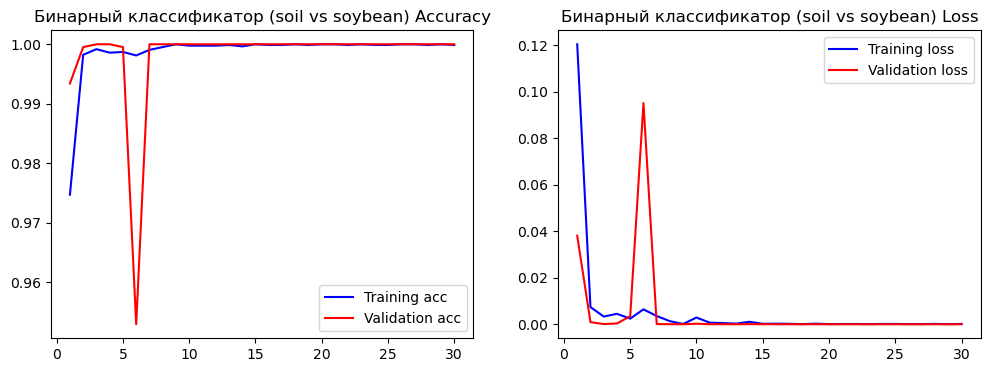

In [14]:
plot_history(history_bin, "Бинарный классификатор (soil vs soybean)")

## Многоклассовый классификатор

In [15]:
## Разделение на train/val/test для многоклассовой
multi_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_multi = multi_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_multi = multi_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_datagen_multi = ImageDataGenerator(rescale=1./255)

test_multi = test_datagen_multi.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Многоклассовые классы:", train_multi.class_indices)

Found 11317 images belonging to 3 classes.
Found 2828 images belonging to 3 classes.
Found 14145 images belonging to 3 classes.
Многоклассовые классы: {'grass': 0, 'soil': 1, 'soybean': 2}


In [16]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [17]:
base_model.trainable = False

model_head = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_head.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_head = model_head.fit(
    train_multi,
    validation_data=val_multi,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

model_head.save("resnet50_head_only_3class.keras")

Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.5689 - loss: 0.9200 - val_accuracy: 0.5697 - val_loss: 0.8870 - learning_rate: 1.0000e-04
Epoch 2/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 325s 919ms/step - accuracy: 0.6754 - loss: 0.7615 - val_accuracy: 0.7203 - val_loss: 0.6680 - learning_rate: 1.0000e-04
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 320s 904ms/step - accuracy: 0.6984 - loss: 0.6996 - val_accuracy: 0.7521 - val_loss: 0.6108 - learning_rate: 1.0000e-04
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 319s 902ms/step - accuracy: 0.7275 - loss: 0.6627 - val_accuracy: 0.7723 - val_loss: 0.5710 - learning_rate: 5.0000e-05
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 319s 900ms/step - accuracy: 0.7363 - loss: 0.6418 - val_accuracy: 0.7825 - val_loss: 0.5572 - learning_rate: 5.0000e-05
Epoch 6/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 315s 891ms/step - accuracy: 0.7415 - loss: 0.6289 - val_accuracy: 0.7825 - val_loss: 0.5495 - learning_rate: 5.0000e-05
Epoch 7/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 324

In [43]:
model_head.summary()

print(f"Всего параметров: {model_head.count_params()}")
print(f"Обучаемых параметров: {sum([np.prod(v.shape) for v in model_head.trainable_weights])}")
print(f"Необучаемых параметров: {sum([np.prod(v.shape) for v in model_head.non_trainable_weights])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,998,091 (91.55 MB)

 Trainable params: 14,585,603 (55.64 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 270,856 (1.03 MB)

Всего параметров: 23727235
Обучаемых параметров: 14585603
Необучаемых параметров: 9141632


In [18]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_fine = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_fine.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model_fine.fit(
    train_multi,
    validation_data=val_multi,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

model_fine.save("resnet50_finetuned_3class.keras")

Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.6106 - loss: 1.0020 - val_accuracy: 0.7023 - val_loss: 0.7091 - learning_rate: 1.0000e-05
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.7361 - loss: 0.6823 - val_accuracy: 0.8388 - val_loss: 0.4094 - learning_rate: 1.0000e-05
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7867 - loss: 0.5550 - val_accuracy: 0.8243 - val_loss: 0.4613 - learning_rate: 1.0000e-05
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.8144 - loss: 0.4911 - val_accuracy: 0.8663 - val_loss: 0.3429 - learning_rate: 5.0000e-06
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.8252 - loss: 0.4643 - val_accuracy: 0.8921 - val_loss: 0.2741 - learning_rate: 5.0000e-06
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.8429 - loss: 0.4043 - val_accuracy: 0.8890 - val_loss: 0.3036 - learning_rate: 5.0000e-06
Epoch 7/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - acc

In [44]:
model_fine.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,656,331 (212.31 MB)

 Trainable params: 15,504,899 (59.15 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 31,009,800 (118.29 MB)

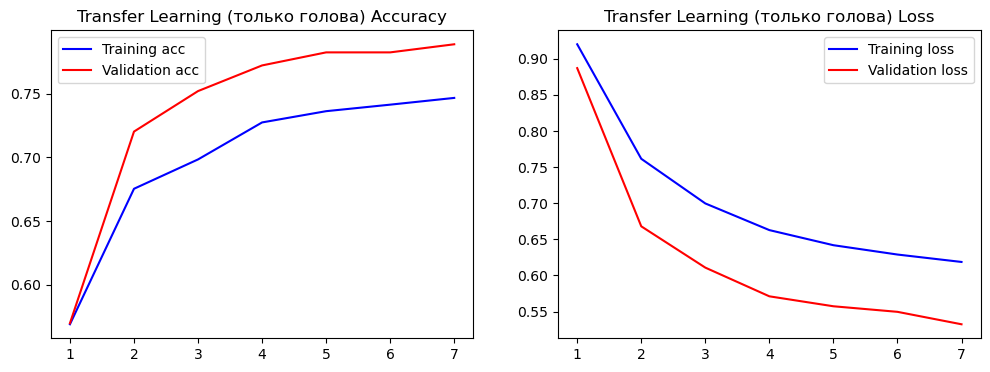

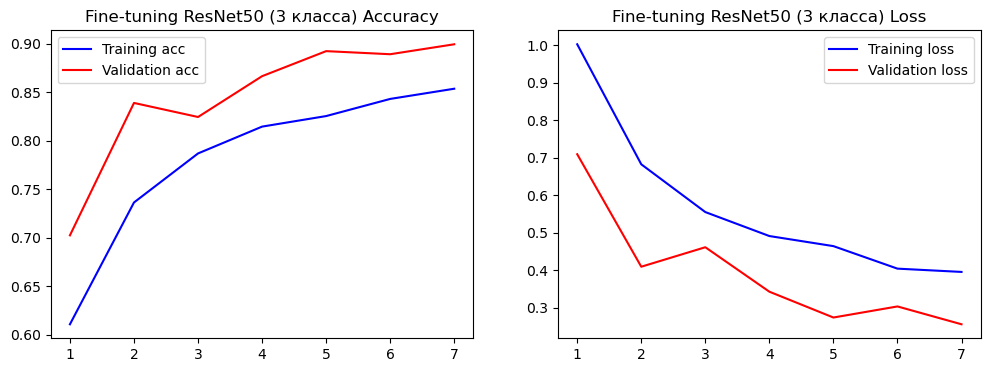

89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 735ms/step - accuracy: 0.6952 - loss: 0.7022

Финальная точность (3 класса, fine-tuning): 0.6952
Порядок классов: {'grass': 0, 'soil': 1, 'soybean': 2}


In [19]:
plot_history(history_head, "Transfer Learning (только голова)")
plot_history(history_fine, "Fine-tuning ResNet50 (3 класса)")

val_loss, val_acc = model_fine.evaluate(val_multi)
print(f"\nФинальная точность (3 класса, fine-tuning): {val_acc:.4f}")
print("Порядок классов:", train_multi.class_indices)

In [20]:
test_loss_bin, test_acc_bin = model_bin.evaluate(test_generator_bin)
print(f"   Test Loss: {test_loss_bin:.4f}")
print(f"   Test Accuracy: {test_acc_bin:.4f}")

333/333 ━━━━━━━━━━━━━━━━━━━━ 37s 111ms/step - accuracy: 1.0000 - loss: 1.3343e-06
   Test Loss: 0.0000
   Test Accuracy: 1.0000


In [21]:
test_loss_head, test_acc_head = model_head.evaluate(test_multi)
print(f"   Test Loss: {test_loss_head:.4f}")
print(f"   Test Accuracy: {test_acc_head:.4f}")

443/443 ━━━━━━━━━━━━━━━━━━━━ 309s 697ms/step - accuracy: 0.2937 - loss: 2.1832
   Test Loss: 2.1832
   Test Accuracy: 0.2937


In [22]:
test_loss_fine, test_acc_fine = model_fine.evaluate(test_multi)
print(f"   Test Loss: {test_loss_fine:.4f}")
print(f"   Test Accuracy: {test_acc_fine:.4f}")

443/443 ━━━━━━━━━━━━━━━━━━━━ 303s 684ms/step - accuracy: 0.6976 - loss: 0.6991
   Test Loss: 0.6991
   Test Accuracy: 0.6976


In [25]:
metrics_df = pd.DataFrame({
    'Модель': ['Бинарный CNN', 'Transfer Learning', 'Fine-tuning'],
    'Test Accuracy': [test_acc_bin, test_acc_head, test_acc_fine],
    'Test Loss': [test_loss_bin, test_loss_head, test_loss_fine]
})

print(metrics_df.to_string(index=False))

           Модель  Test Accuracy  Test Loss
     Бинарный CNN       1.000000   0.000001
Transfer Learning       0.293743   2.183212
      Fine-tuning       0.697561   0.699118


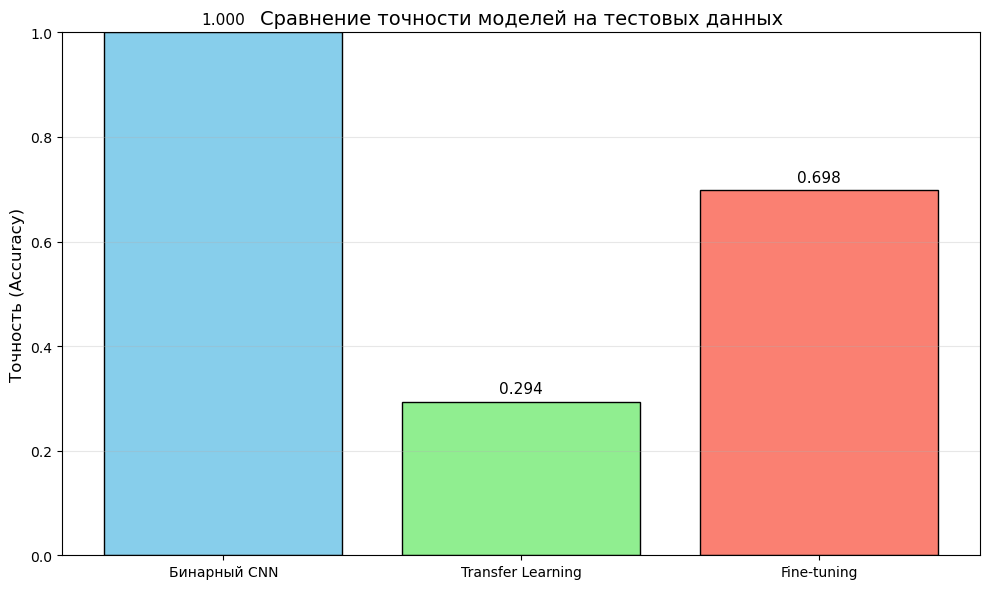

In [26]:
plt.figure(figsize=(10, 6))
models_names = ['Бинарный CNN', 'Transfer Learning', 'Fine-tuning']
accuracies = [test_acc_bin, test_acc_head, test_acc_fine]
colors = ['skyblue', 'lightgreen', 'salmon']

bars = plt.bar(models_names, accuracies, color=colors, edgecolor='black')
plt.title('Сравнение точности моделей на тестовых данных', fontsize=14)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.ylim(0, 1.0)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [28]:
y_pred_head = model_head.predict(test_multi)
y_pred_head_classes = np.argmax(y_pred_head, axis=1)
y_true = test_multi.classes

443/443 ━━━━━━━━━━━━━━━━━━━━ 311s 698ms/step


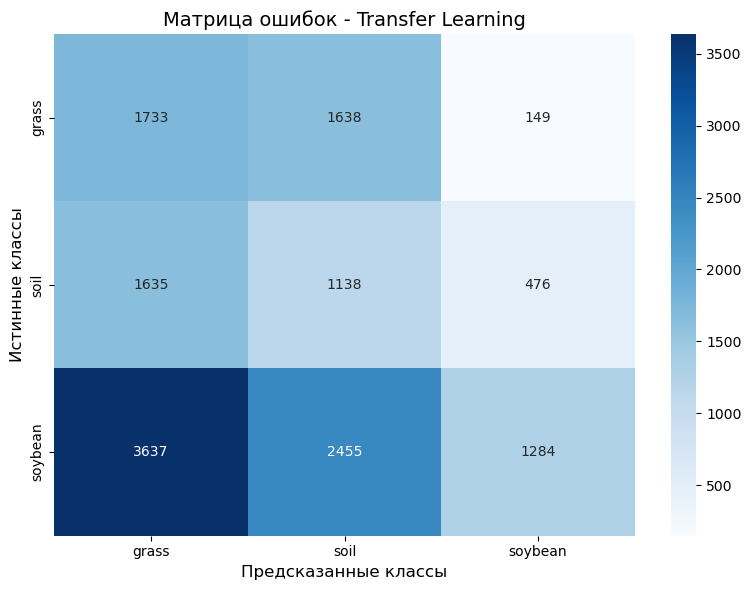

In [29]:
# Матрица ошибок для Transfer Learning
cm_head = confusion_matrix(y_true, y_pred_head_classes)
class_names = list(test_multi.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm_head, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок - Transfer Learning', fontsize=14)
plt.ylabel('Истинные классы', fontsize=12)
plt.xlabel('Предсказанные классы', fontsize=12)
plt.tight_layout()
plt.show()

443/443 ━━━━━━━━━━━━━━━━━━━━ 302s 678ms/step


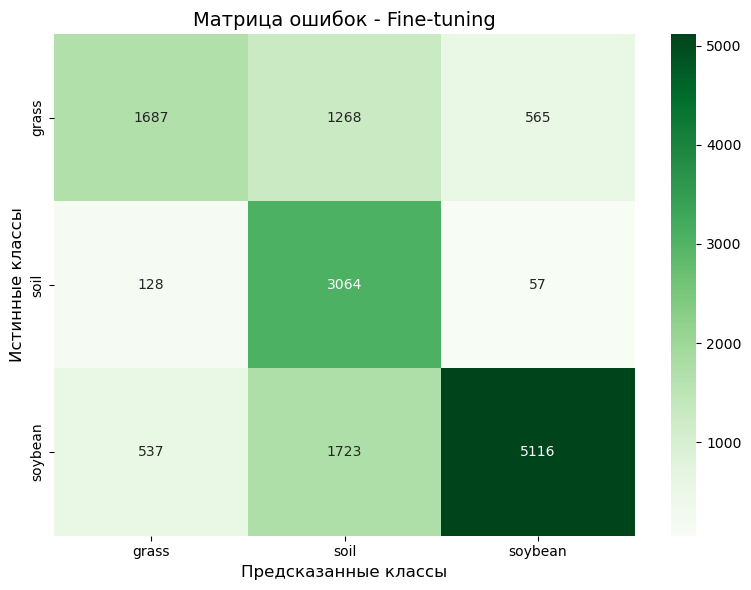

In [30]:
y_pred_fine = model_fine.predict(test_multi)
y_pred_fine_classes = np.argmax(y_pred_fine, axis=1)

# Матрица ошибок для Fine-tuning
cm_fine = confusion_matrix(y_true, y_pred_fine_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_fine, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок - Fine-tuning', fontsize=14)
plt.ylabel('Истинные классы', fontsize=12)
plt.xlabel('Предсказанные классы', fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import precision_recall_fscore_support

In [32]:
precision_head, recall_head, f1_head, _ = precision_recall_fscore_support(
    y_true, y_pred_head_classes, average=None, labels=[0, 1, 2]
)

precision_fine, recall_fine, f1_fine, _ = precision_recall_fscore_support(
    y_true, y_pred_fine_classes, average=None, labels=[0, 1, 2]
)

# Создаем DataFrame для сравнения
class_metrics_df = pd.DataFrame({
    'Класс': class_names * 2,
    'Модель': ['Transfer Learning']*3 + ['Fine-tuning']*3,
    'Precision': list(precision_head) + list(precision_fine),
    'Recall': list(recall_head) + list(recall_fine),
    'F1-score': list(f1_head) + list(f1_fine)
})

print("\nМетрики по классам:")
print(class_metrics_df.to_string(index=False))


Метрики по классам:
  Класс            Модель  Precision   Recall  F1-score
  grass Transfer Learning   0.247395 0.492330  0.329311
   soil Transfer Learning   0.217549 0.350262  0.268396
soybean Transfer Learning   0.672603 0.174078  0.276575
  grass       Fine-tuning   0.717262 0.479261  0.574591
   soil       Fine-tuning   0.506028 0.943059  0.658641
soybean       Fine-tuning   0.891600 0.693601  0.780235


In [33]:
## диграмма сравнения по классам

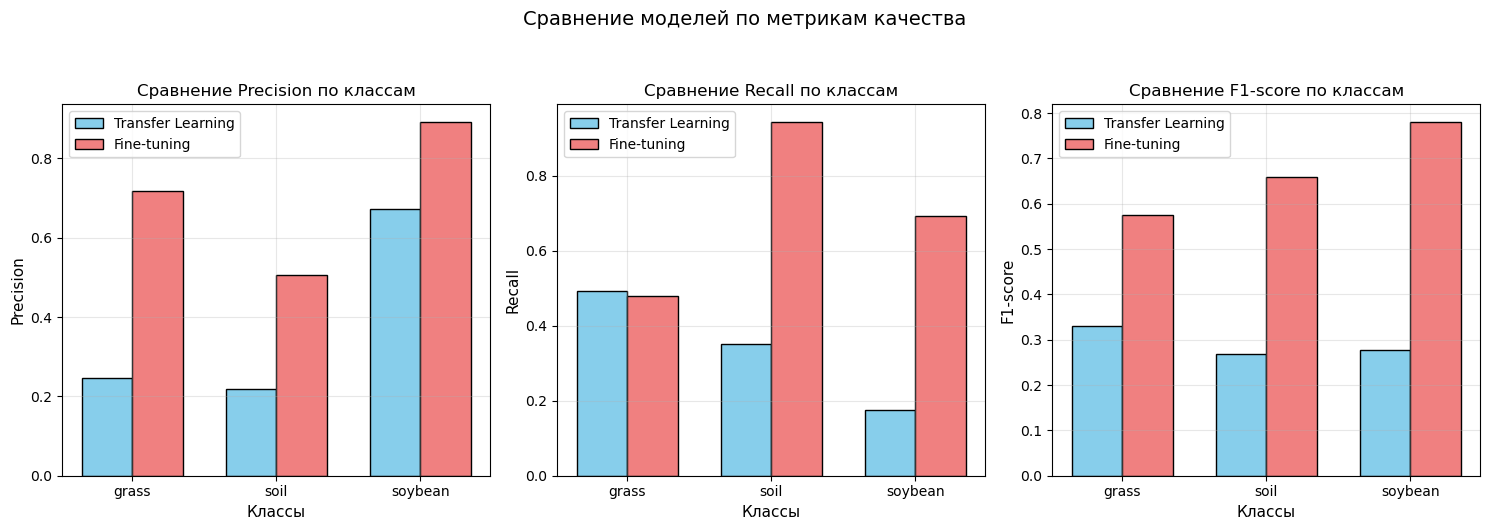

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Precision', 'Recall', 'F1-score']
colors = ['skyblue', 'lightcoral']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    tl_data = class_metrics_df[class_metrics_df['Модель'] == 'Transfer Learning'][metric].values
    
    ft_data = class_metrics_df[class_metrics_df['Модель'] == 'Fine-tuning'][metric].values
    
    x = np.arange(len(class_names))
    width = 0.35
    
    ax.bar(x - width/2, tl_data, width, label='Transfer Learning', color=colors[0], edgecolor='black')
    ax.bar(x + width/2, ft_data, width, label='Fine-tuning', color=colors[1], edgecolor='black')
    
    ax.set_xlabel('Классы', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'Сравнение {metric} по классам', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Сравнение моделей по метрикам качества', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [35]:
## Сводная таблица  метрик
full_metrics_df = pd.DataFrame({
    'Модель': ['Бинарный CNN', 'Transfer Learning', 'Fine-tuning'],
    'Test Accuracy': [test_acc_bin, test_acc_head, test_acc_fine],
    'Test Loss': [test_loss_bin, test_loss_head, test_loss_fine],
    'Avg Precision': ['-', np.mean(precision_head), np.mean(precision_fine)],
    'Avg Recall': ['-', np.mean(recall_head), np.mean(recall_fine)],
    'Avg F1-score': ['-', np.mean(f1_head), np.mean(f1_fine)]
})

print(full_metrics_df.to_string(index=False, float_format='{:.4f}'.format))

print("\nПорядок классов:", train_multi.class_indices)

           Модель  Test Accuracy  Test Loss Avg Precision Avg Recall Avg F1-score
     Бинарный CNN         1.0000     0.0000             -          -            -
Transfer Learning         0.2937     2.1832        0.3792     0.3389       0.2914
      Fine-tuning         0.6976     0.6991        0.7050     0.7053       0.6712

Порядок классов: {'grass': 0, 'soil': 1, 'soybean': 2}


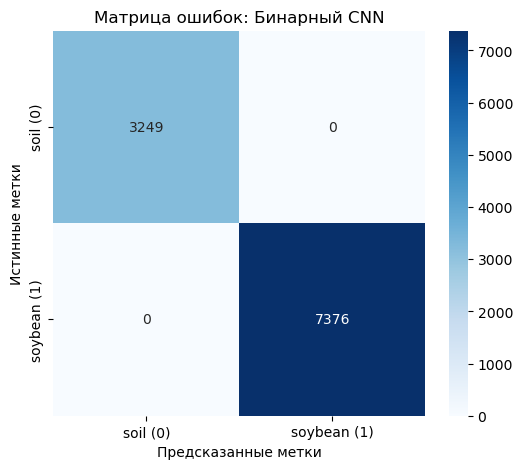

In [38]:
# 1. Для бинарной классификации

test_generator_bin.reset()  # Сбрасываем генератор
y_pred_prob_bin = model_bin.predict(test_generator_bin, verbose=0)
y_pred_bin = (y_pred_prob_bin > 0.5).astype(int).flatten()
y_true_bin = test_generator_bin.classes

# Матрица ошибок
cm_bin = confusion_matrix(y_true_bin, y_pred_bin)

# Визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['soil (0)', 'soybean (1)'],
            yticklabels=['soil (0)', 'soybean (1)'])
plt.title('Матрица ошибок: Бинарный CNN')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.show()

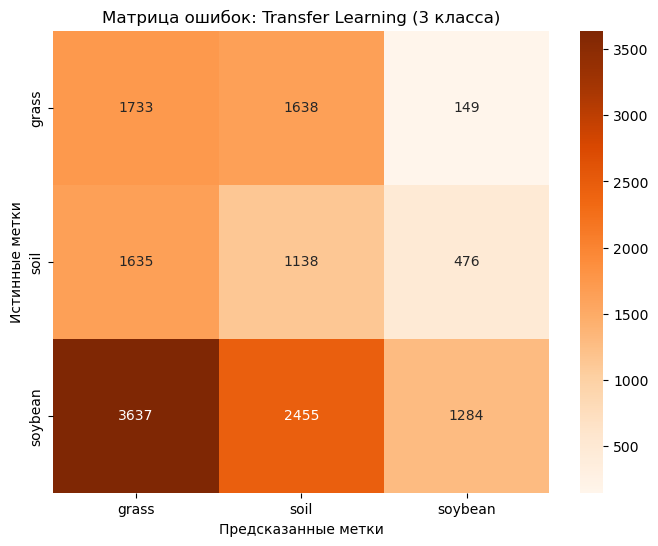

In [39]:
# 2. Для многоклассовой классификации (Transfer Learning)
test_multi.reset()
y_pred_prob_head = model_head.predict(test_multi, verbose=0)
y_pred_head = np.argmax(y_pred_prob_head, axis=1)
y_true_multi = test_multi.classes

cm_head = confusion_matrix(y_true_multi, y_pred_head)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm_head, annot=True, fmt='d', cmap='Oranges',
            xticklabels=list(train_multi.class_indices.keys()),
            yticklabels=list(train_multi.class_indices.keys()))
plt.title('Матрица ошибок: Transfer Learning (3 класса)')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.show()


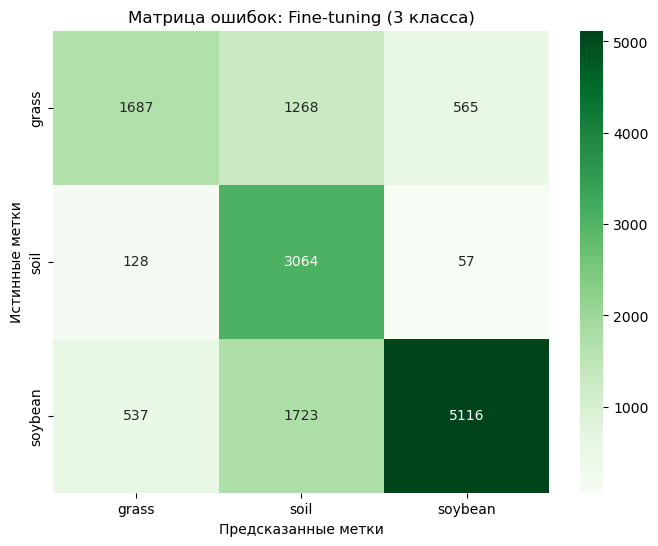

In [40]:
# 3. Для многоклассовой классификации (Fine-tuning)

test_multi.reset()
y_pred_prob_fine = model_fine.predict(test_multi, verbose=0)
y_pred_fine = np.argmax(y_pred_prob_fine, axis=1)

cm_fine = confusion_matrix(y_true_multi, y_pred_fine)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm_fine, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(train_multi.class_indices.keys()),
            yticklabels=list(train_multi.class_indices.keys()))
plt.title('Матрица ошибок: Fine-tuning (3 класса)')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.show()